**CSI 4106 Introduction to Artificial Intelligence**  
*Assignment 1: Deep-Sea Mission Data Preparation*  
*Due: October 5, 2026, at 11 PM*

# Identification
 
Report title: Deep-Sea Mission Dataset Cleaning   

# 1. Data and objective

The fictional **Abyssal Survey and Robotics Centre (ASRC)** operates
autonomous underwater vehicles for seabed mapping, environmental
monitoring, and deep-ocean surveys. Each row represents one mission. The
predictors are available before the main survey begins. The response,
`mission_interrupted`, is `1` when the vehicle returned before
completing its planned survey and `0` otherwise.

The data are fully synthetic and were created for teaching.

- [Assignment 1 data
  directory](https://github.com/turcotte/csi4106-f26/tree/main/assignments-data/a1)
- [asrc_missions_raw.csv](https://raw.githubusercontent.com/turcotte/csi4106-f26/main/assignments-data/a1/asrc_missions_raw.csv)

Consult the assignment handout for the variable descriptions and ASRC
operating context.

# 2. Data preparation and exploratory analysis

# 2.1 Load and audit the dataset

Load the supplied CSV data. The notebook must remain able to obtain the
source file from the supplied GitHub URL without a manual upload. Report
its shape, first five rows, initial data types, and number of distinct
values per column.

# **IMPORTANT**
### - Smaller 1-2 code block analyses have their Conclusion / Finding within the code block in `#comments`
### - Bigger section-wide Conclusions / Findings have their own `Markdown` blocks
#### - My reasoning is *linear*, not *modular*, so please read a block at a time, don't skip to end of sections

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/turcotte/csi4106-f26/main/assignments-data/a1/asrc_missions_raw.csv")

### Dataset Shape

In [83]:
df.shape

(6371, 17)

### First five rows

In [84]:
df.head(5)

,mission_id,deployment_batch,telemetry_protocol,planned_depth_m,planned_depth_ft,descent_current_speed_m_s,water_temperature_c,sonar_noise_db,navigation_drift_m,battery_health_pct,thruster_vibration_mm_s,missions_since_service,vehicle_class,seabed_terrain,maintenance_grade,firmware_current,mission_interrupted
0,ASRC-M000001,ASRC-B0253,asrc_tlm_v4,1400.0,4593.2,0.55,3.3000000000000003,66.0,10.4,87.0,3.1,14,compact,ridge,good,1,0
1,ASRC-M000002,ASRC-B0648,asrc_tlm_v4,2700.0,8858.3,0.68,3.0,78.5,49.900000000000006,83.0,3.9,4,heavy_duty,vent_field,good,1,1
2,ASRC-M000003,ASRC-B0340,asrc_tlm_v4,2870.0,9416.0,0.15,3.6,78.7,5.800000000000001,92.0,5.2,10,survey,vent_field,fair,1,1
3,ASRC-M000004,ASRC-B0620,asrc_tlm_v4,2840.0,9317.6,0.39,2.5,77.30000000000001,54.6,89.0,3.9,9,survey,trench,good,1,0
4,ASRC-M000005,ASRC-B0332,asrc_tlm_v4,2430.0,7972.4,0.34,2.8000000000000003,77.80000000000001,8.700000000000001,89.0,3.4000000000000004,8,heavy_duty,vent_field,excellent,1,0


### Initial Data Types

In [85]:
df.dtypes

mission_id                       str
deployment_batch                 str
telemetry_protocol               str
planned_depth_m              float64
planned_depth_ft             float64
descent_current_speed_m_s    float64
water_temperature_c              str
sonar_noise_db                   str
navigation_drift_m               str
battery_health_pct               str
thruster_vibration_mm_s          str
missions_since_service         int64
vehicle_class                    str
seabed_terrain                   str
maintenance_grade                str
firmware_current               int64
mission_interrupted            int64
dtype: object

### Number of distinct values per column

In [86]:
df.nunique()

mission_id                   6371
deployment_batch              850
telemetry_protocol              2
planned_depth_m               582
planned_depth_ft              576
descent_current_speed_m_s     173
water_temperature_c           131
sonar_noise_db                339
navigation_drift_m            709
battery_health_pct             33
thruster_vibration_mm_s       192
missions_since_service         53
vehicle_class                   9
seabed_terrain                 12
maintenance_grade              13
firmware_current                2
mission_interrupted             2
dtype: int64

# 2.2 Handle missing values and data types

Investigate empty fields, `NA`, and `?`; convert them to `NaN`. Convert
numeric-like columns to numeric types, with parsing failures becoming
`NaN`. Report missing counts and percentages. Do not impute.

## Viewing empty fields

In [87]:
df[(df.isna() | df.eq("?")).any(axis=1)]

,mission_id,deployment_batch,telemetry_protocol,planned_depth_m,planned_depth_ft,descent_current_speed_m_s,water_temperature_c,sonar_noise_db,navigation_drift_m,battery_health_pct,thruster_vibration_mm_s,missions_since_service,vehicle_class,seabed_terrain,maintenance_grade,firmware_current,mission_interrupted
13,ASRC-M000014,ASRC-B0798,asrc_tlm_v4,3220.0,10564.3,0.21,1.6,66.9,NaN,83.0,7.9,16,compact,trench,good,0,0
38,ASRC-M000039,ASRC-B0105,asrc_tlm_v4,680.0,2231.0,0.17,7.0,64.0,16.900000000000002,93.0,0.7000000000000001,4,survey,plain,NaN,0,1
40,ASRC-M000041,ASRC-B0627,asrc_tlm_v4,1000.0,3280.8,0.66,4.4,64.60000000000001,35.5,NaN,0.2,8,compact,plain,excellent,0,0
60,ASRC-M000061,ASRC-B0643,asrc_tlm_v4,520.0,1706.0,0.19,11.1,NaN,6.300000000000001,87.0,2.1,9,compact,plain,good,1,1
65,ASRC-M000066,ASRC-B0504,asrc_tlm_v4,460.0,1509.2,0.29,NaN,65.7,3.5,81.0,NaN,39,survey,plain,poor,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6335,ASRC-M006336,ASRC-B0253,asrc_tlm_v4,890.0,2919.9,0.39,3.7,73.2,10.3,87.0,NaN,5,heavy_duty,plain,good,1,0
6342,ASRC-M006343,ASRC-B0460,asrc_tlm_v4,550.0,1804.5,0.22,5.0,?,3.7,86.0,3.0,3,compact,plain,good,1,0
6344,ASRC-M006345,ASRC-B0702,asrc_tlm_v4,1780.0,5839.9,1.21,NaN,79.2,37.9,96.0,2.8000000000000003,5,survey,ridge,excellent,1,0
6345,ASRC-M006346,ASRC-B0148,asrc_tlm_v4,1630.0,5347.8,0.40,2.3000000000000003,?,18.0,89.0,2.8000000000000003,5,heavy_duty,ridge,NaN,1,0


### Empty fields count

In [88]:
(df.eq("?") | df.isna()).sum().sum()
# There are 814 missing values (NA, NaN and '?')

np.int64(814)

## Converting numeric-like columns to numeric types, with parsing failures becoming `NaN`.

In [89]:
numeric_cols = ["planned_depth_m", 
                "planned_depth_ft", 
                "descent_current_speed_m_s", 
                "water_temperature_c", 
                "sonar_noise_db", 
                "navigation_drift_m", 
                "battery_health_pct", 
                "thruster_vibration_mm_s", 
                "missions_since_service",
               ]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

## Converting categorical-like columns to categorical types, with parsing failures becoming `NaN`.

In [90]:
categorical_cols = ["deployment_batch", 
                "telemetry_protocol", 
                "vehicle_class", 
                "seabed_terrain", 
                "maintenance_grade", 
               ]

df[categorical_cols] = df[categorical_cols].replace('?', np.nan).astype('category')

## Missing count report

In [91]:
df.isna().sum()

mission_id                     0
deployment_batch               0
telemetry_protocol             0
planned_depth_m                0
planned_depth_ft               0
descent_current_speed_m_s      0
water_temperature_c          169
sonar_noise_db               123
navigation_drift_m           120
battery_health_pct           147
thruster_vibration_mm_s      126
missions_since_service         0
vehicle_class                  0
seabed_terrain                 0
maintenance_grade            129
firmware_current               0
mission_interrupted            0
dtype: int64

In [92]:
(df.eq("?") | df.isna()).sum()

mission_id                     0
deployment_batch               0
telemetry_protocol             0
planned_depth_m                0
planned_depth_ft               0
descent_current_speed_m_s      0
water_temperature_c          169
sonar_noise_db               123
navigation_drift_m           120
battery_health_pct           147
thruster_vibration_mm_s      126
missions_since_service         0
vehicle_class                  0
seabed_terrain                 0
maintenance_grade            129
firmware_current               0
mission_interrupted            0
dtype: int64

# 2.3 Clean categorical attributes

Inspect every predictor represented by repeated text labels for
inconsistent category representations. Evaluate identifiers and
administrative codes in Task 2.6 rather than standardizing them merely
because they are text. Describe your investigation and cleaning method,
consolidate inconsistent labels where necessary, and show frequencies or
values before and after cleaning. Identify and state any meaningful
ordering among category levels.

## maintenance_grade Analysis

In [93]:
df['maintenance_grade'].value_counts()

maintenance_grade
good         2481
excellent    2090
fair         1159
poor          416
Good           24
EXCELLENT      23
Excellent      18
 good          17
Poor            6
FAIR            5
Fair            2
 poor           1
Name: count, dtype: int64

### Lots of the same words, written differently. They need to be aggregated for proper classification.

## maintenance_grade Cleaning

In [94]:
df['maintenance_grade'] = df['maintenance_grade'].str.strip().str.lower()
# Funnels all text formats into clean aggregated categories

df['maintenance_grade'].value_counts()
# Proof of funnelling

maintenance_grade
good         2522
excellent    2131
fair         1166
poor          423
Name: count, dtype: int64

## seabed_terrain Analysis

In [95]:
df['seabed_terrain'].value_counts()

seabed_terrain
plain         2310
ridge         1770
trench        1223
vent_field     972
 plain          20
Plain           17
Ridge           14
 trench         13
RIDGE           10
Trench           9
Vent Field       8
vent-field       5
Name: count, dtype: int64

### Lots of the same words, written differently. They need to be aggregated for proper classification.

## seabed_terrain Cleaning

In [96]:
df['seabed_terrain'] = df['seabed_terrain'].str.strip().str.lower()
# Funnels string case formats into clean aggregated categories

vent_field_replace = {
    'Vent Field' : 'vent_field',
    'vent-field' : 'vent_field',
    'vent field' : 'vent_field'
}
#Takes care of the '-' , '_' and ' ' cases.

df['seabed_terrain'] = df['seabed_terrain'].replace(vent_field_replace)
# Replace the mapped items

df['seabed_terrain'].value_counts()
# Proof of funnelling

seabed_terrain
plain         2347
ridge         1794
trench        1245
vent_field     985
Name: count, dtype: int64

## vehicle_class Analysis

In [97]:
df['vehicle_class'].value_counts()

vehicle_class
survey        3140
compact       1843
heavy_duty    1292
SURVEY          31
Survey          18
 compact        15
Compact         13
Heavy Duty      11
heavy-duty       8
Name: count, dtype: int64

### Lots of the same words, written differently. They need to be aggregated for proper classification.

## vehicle_class Cleaning

In [98]:
df['vehicle_class'] = df['vehicle_class'].str.strip().str.lower()
# Funnels string case formats into clean aggregated categories

vehicle_class_replace = {
    'heavy duty' : 'heavy_duty',
    'heavy-duty' : 'heavy_duty',
}
#Takes care of the '-' and '_' cases.

df['vehicle_class'] = df['vehicle_class'].replace(vehicle_class_replace)
# Replace the mapped items

df['vehicle_class'].value_counts()
# Proof of funnelling

vehicle_class
survey        3189
compact       1871
heavy_duty    1311
Name: count, dtype: int64

## telemetry_protocol Analysis

In [99]:
df['telemetry_protocol'].value_counts()
# No need for futher analysis, text is concise throughout 
# and shows clear upgrade to newer telemetry protocol

telemetry_protocol
asrc_tlm_v4    6318
asrc_tlm_v3      53
Name: count, dtype: int64

## deployment_batch Analysis

In [100]:
print(df['deployment_batch'].value_counts())
# Value count analysis, doesn't show us clear cleaning possibilities

print("--------------------")

print(df['deployment_batch'].nunique())
# Unique row count, doesn't show us clear cleaning possibilities

print("--------------------")

print(df['deployment_batch'].unique())
# Name uniqueness, doesn't show us clear cleaning possibilities

deployment_batch
ASRC-B0001    8
ASRC-B0002    8
ASRC-B0003    8
ASRC-B0004    8
ASRC-B0005    8
             ..
ASRC-B0846    7
ASRC-B0847    7
ASRC-B0848    7
ASRC-B0849    7
ASRC-B0850    7
Name: count, Length: 850, dtype: int64
--------------------
850
--------------------
['ASRC-B0253', 'ASRC-B0648', 'ASRC-B0340', 'ASRC-B0620', 'ASRC-B0332', ..., 'ASRC-B0838', 'ASRC-B0288', 'ASRC-B0478', 'ASRC-B0277', 'ASRC-B0807']
Length: 850
Categories (850, str): ['ASRC-B0001', 'ASRC-B0002', 'ASRC-B0003', 'ASRC-B0004', ..., 'ASRC-B0847', 'ASRC-B0848', 'ASRC-B0849', 'ASRC-B0850']


## deployment_batch Format Check

In [101]:
valid_format = df['deployment_batch'].str.fullmatch(r'ASRC-B\d{4}')
# Check for format of deployment_batch text

df[~valid_format]
# Assigns True or False to every row depending on if they have the correct format or not

valid_format.all()
# This check shows all rows abide by the correct format, 
# therefore this categorical attribute is clean

np.True_

## mission_id Analysis

In [102]:
print(df['mission_id'].nunique())
print(len(df))
# No need for futher analysis, there are as many unique mission_id's
# as there are rows in the dataset

6371
6371


# 2.4 Apply validity rules

Use the variable meanings, units, and ASRC operating context to define
and justify validation rules. Report the affected attributes and counts,
replace invalid measurements with `NaN`, and retain unusual but possible
observations. Do not guess corrections, reconstruct values from another
column, or remove entire missions.

## Attributes that I deem require overview
- battery_health: for any values outside of 0-100
- planned_depth_m / planned_depth_ft for any negative values and outliers
- descent_current_speed_m_s for any negative values and outliers
- water_temperature_c for any outliers
- sonar_noise_db for any negative values and outliers
- thruster_vibration_mm_s for any negative values and outliers
- navigation_drift_m for any negative values and outliers
- missions_since_service for any negative values and outliers

## battery_health_pct Range Check

In [103]:
df[~df['battery_health_pct'].between(0, 100) & df['battery_health_pct'].notna()]
# Check for invalid bettery_health range values.

,mission_id,deployment_batch,telemetry_protocol,planned_depth_m,planned_depth_ft,descent_current_speed_m_s,water_temperature_c,sonar_noise_db,navigation_drift_m,battery_health_pct,thruster_vibration_mm_s,missions_since_service,vehicle_class,seabed_terrain,maintenance_grade,firmware_current,mission_interrupted
1620,ASRC-M001621,ASRC-B0695,asrc_tlm_v4,3630.0,11909.4,0.33,1.9,80.4,47.4,108.0,12.3,8,heavy_duty,trench,good,1,1
1936,ASRC-M001937,ASRC-B0084,asrc_tlm_v4,2520.0,8267.7,0.56,2.4,72.8,26.8,108.0,2.4,17,compact,vent_field,good,0,1
2159,ASRC-M002160,ASRC-B0409,asrc_tlm_v4,620.0,2034.1,0.40,8.6,69.9,37.4,108.0,2.3,11,survey,plain,good,0,1
4694,ASRC-M004695,ASRC-B0429,asrc_tlm_v4,840.0,2755.9,0.75,3.5,67.1,34.7,108.0,4.8,5,compact,ridge,excellent,1,0
5700,ASRC-M005701,ASRC-B0483,asrc_tlm_v4,1720.0,5643.0,0.13,2.6,74.9,8.5,108.0,1.7,6,heavy_duty,ridge,fair,1,1
6196,ASRC-M006197,ASRC-B0115,asrc_tlm_v4,680.0,2231.0,0.07,7.4,NaN,3.0,108.0,2.4,10,compact,plain,excellent,1,0


### 6 rows have batter_health_pct values outside the accepted range

In [104]:
(df['battery_health_pct'].isna()).value_counts()
# Currently, 147 battery_health_pct are NaN

battery_health_pct
False    6224
True      147
Name: count, dtype: int64

In [105]:
outside_range = ~df['battery_health_pct'].between(0, 100) & df['battery_health_pct'].notna()
df.loc[outside_range, 'battery_health_pct'] = np.nan
# Make the found Invalid values into NaN

print((df['battery_health_pct'].isna()).value_counts())
# Show that 6 new NaN's have been added (153 now, instead of 147 from earlier)

print((~df['battery_health_pct'].between(0, 100) | df['battery_health_pct'].notna()).value_counts())
# Show that all rows contain elements that are within 0 - 100 or NaN, nothing else.

battery_health_pct
False    6218
True      153
Name: count, dtype: int64
battery_health_pct
True    6371
Name: count, dtype: int64


## planned_depth_m Negative Check

In [106]:
df[df['planned_depth_m'] < 0]
# Shows no rows that have negative values

,mission_id,deployment_batch,telemetry_protocol,planned_depth_m,planned_depth_ft,descent_current_speed_m_s,water_temperature_c,sonar_noise_db,navigation_drift_m,battery_health_pct,thruster_vibration_mm_s,missions_since_service,vehicle_class,seabed_terrain,maintenance_grade,firmware_current,mission_interrupted


## planned_depth_m Outlier Check

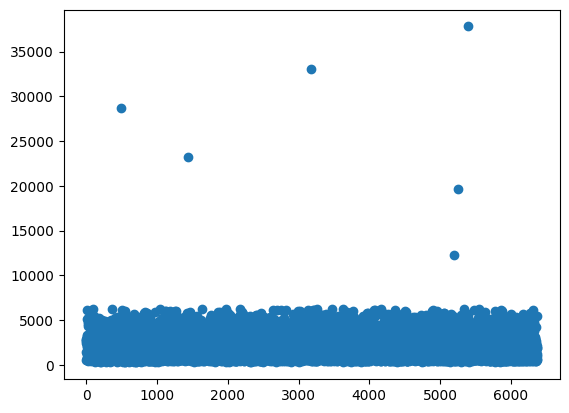

In [107]:
plt.scatter(df.index, df['planned_depth_m'])
plt.show()
# 6 clear outliers here

## planned_depth_m Outlier Cleaning

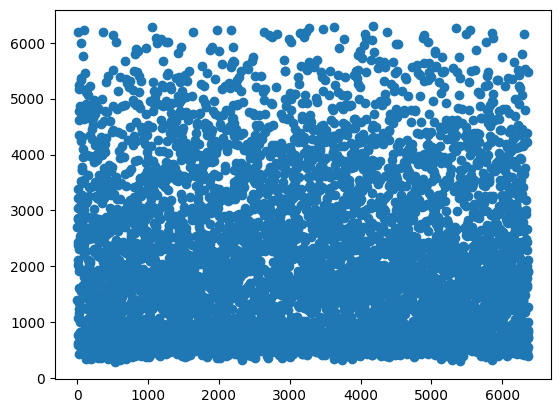

In [108]:
outside_range = df['planned_depth_m'] > 10000
df.loc[outside_range, 'planned_depth_m'] = np.nan
# Make the found values into NaN

plt.scatter(df.index, df['planned_depth_m'])
plt.show()
#Show new graph, with outlying values being NaN

## planned_depth_ft Negative Check

In [109]:
df[df['planned_depth_ft'] < 0]
# Shows no rows that have negative values

,mission_id,deployment_batch,telemetry_protocol,planned_depth_m,planned_depth_ft,descent_current_speed_m_s,water_temperature_c,sonar_noise_db,navigation_drift_m,battery_health_pct,thruster_vibration_mm_s,missions_since_service,vehicle_class,seabed_terrain,maintenance_grade,firmware_current,mission_interrupted


## planned_depth_ft Outlier Check

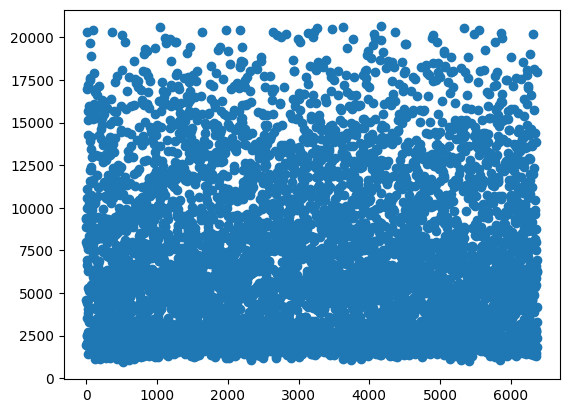

In [110]:
plt.scatter(df.index, df['planned_depth_ft'])
plt.show()
# No clear outliers shown here

## descent_current_speed_m_s Negative Check

In [111]:
( (df['descent_current_speed_m_s'] < 0) & df['descent_current_speed_m_s'].notna() ).value_counts()
# Identified 6 rows that have negative descent_current_speed_m_s values.

descent_current_speed_m_s
False    6365
True        6
Name: count, dtype: int64

In [112]:
df[((df['descent_current_speed_m_s'] < 0) & df['descent_current_speed_m_s'].notna())]
# Show the Invalid values, to see what were working with

,mission_id,deployment_batch,telemetry_protocol,planned_depth_m,planned_depth_ft,descent_current_speed_m_s,water_temperature_c,sonar_noise_db,navigation_drift_m,battery_health_pct,thruster_vibration_mm_s,missions_since_service,vehicle_class,seabed_terrain,maintenance_grade,firmware_current,mission_interrupted
298,ASRC-M000299,ASRC-B0064,asrc_tlm_v4,1940.0,6364.8,-0.43,2.3,68.7,13.2,79.0,4.6,28,compact,ridge,fair,1,1
3598,ASRC-M003599,ASRC-B0777,asrc_tlm_v4,2060.0,6758.5,-1.21,2.3,78.9,27.5,84.0,5.3,25,survey,ridge,fair,1,1
4559,ASRC-M004560,ASRC-B0314,asrc_tlm_v4,420.0,1378.0,-0.15,6.0,60.6,4.5,85.0,8.9,21,compact,plain,good,1,0
5803,ASRC-M005804,ASRC-B0770,asrc_tlm_v4,2580.0,8464.6,-0.84,1.7,85.2,38.5,81.0,2.9,19,heavy_duty,vent_field,fair,1,1
5994,ASRC-M005995,ASRC-B0378,asrc_tlm_v4,2390.0,7841.2,-0.06,3.7,73.1,9.9,87.0,NaN,27,survey,vent_field,good,1,0
6119,ASRC-M006120,ASRC-B0021,asrc_tlm_v4,1510.0,4954.1,-0.41,1.6,67.8,26.9,89.0,3.6,11,compact,ridge,excellent,1,0


## descent_current_speed_m_s Negative Values Cleaning

In [113]:
outside_range = (df['descent_current_speed_m_s'] < 0) & df['descent_current_speed_m_s'].notna()
df.loc[outside_range, 'descent_current_speed_m_s'] = np.nan
# Make the found Invalid values into NaN

( (df['descent_current_speed_m_s'] < 0) & df['descent_current_speed_m_s'].notna() ).value_counts()
# Show that no more rows are negative

descent_current_speed_m_s
False    6371
Name: count, dtype: int64

## descent_current_speed_m_s Outlier Check

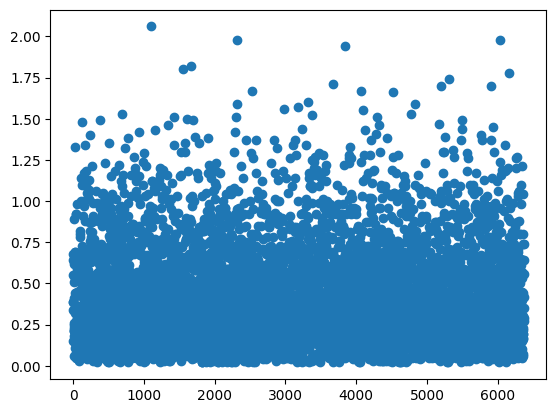

In [114]:
plt.scatter(df.index, df['descent_current_speed_m_s'])
plt.show()
# No clear outliers seen in graph

## water_temperature_c Outlier Check

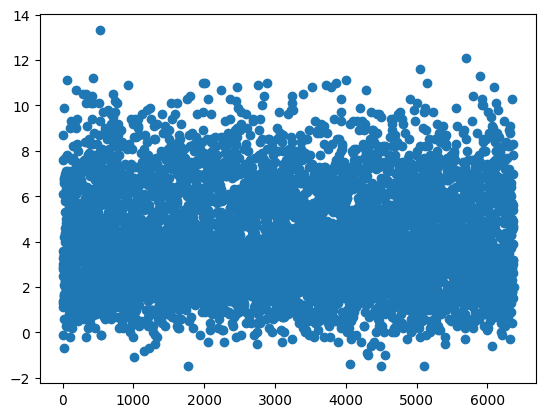

In [115]:
plt.scatter(df.index, df['water_temperature_c'])
plt.show()
# No clear outliers seen in graph

## sonar_noise_db Negative Check

In [116]:
df[((df['sonar_noise_db'] < 0) & df['sonar_noise_db'].notna())]
# Shows no rows that have negative values

,mission_id,deployment_batch,telemetry_protocol,planned_depth_m,planned_depth_ft,descent_current_speed_m_s,water_temperature_c,sonar_noise_db,navigation_drift_m,battery_health_pct,thruster_vibration_mm_s,missions_since_service,vehicle_class,seabed_terrain,maintenance_grade,firmware_current,mission_interrupted


## sonar_noise_db Outlier Check

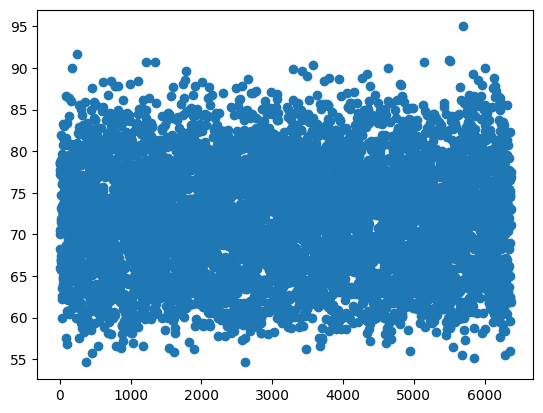

In [117]:
plt.scatter(df.index, df['sonar_noise_db'])
plt.show()
# No clear outliers seen in graph

## thruster_vibration_mm_s Negative Check

In [118]:
df[((df['thruster_vibration_mm_s'] < 0) & df['thruster_vibration_mm_s'].notna())]
# Shows no rows that have negative values

,mission_id,deployment_batch,telemetry_protocol,planned_depth_m,planned_depth_ft,descent_current_speed_m_s,water_temperature_c,sonar_noise_db,navigation_drift_m,battery_health_pct,thruster_vibration_mm_s,missions_since_service,vehicle_class,seabed_terrain,maintenance_grade,firmware_current,mission_interrupted


## thruster_vibration_mm_s Outlier Check

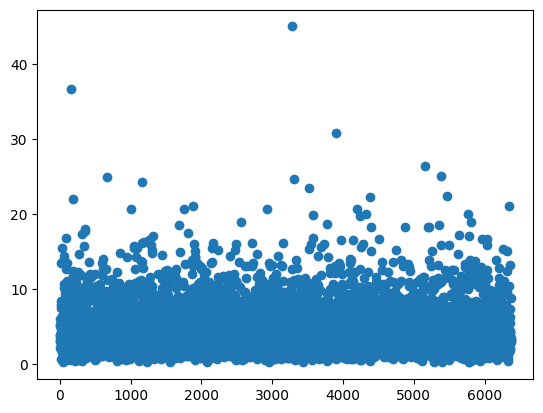

In [119]:
plt.scatter(df.index, df['thruster_vibration_mm_s'])
plt.show()
# Some Outlying values, but not grandiose outliers. I don't hold enough context to know if they truly are anomalies.

## navigation_drift_m Negative Check

In [120]:
df[((df['navigation_drift_m'] < 0) & df['navigation_drift_m'].notna())]
# Shows no rows that have negative values

,mission_id,deployment_batch,telemetry_protocol,planned_depth_m,planned_depth_ft,descent_current_speed_m_s,water_temperature_c,sonar_noise_db,navigation_drift_m,battery_health_pct,thruster_vibration_mm_s,missions_since_service,vehicle_class,seabed_terrain,maintenance_grade,firmware_current,mission_interrupted


## navigation_drift_m Outlier Check

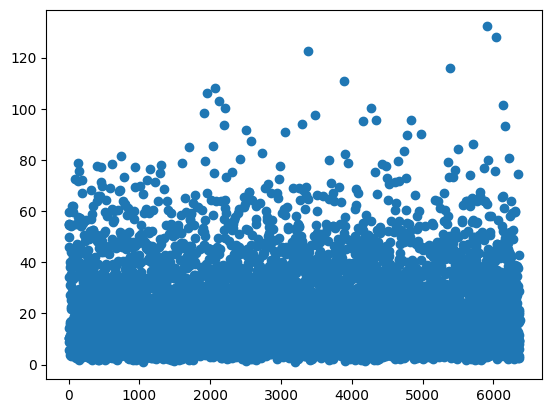

In [121]:
plt.scatter(df.index, df['navigation_drift_m'])
plt.show()
# No clear outliers seen in graph

## missions_since_service Negative Check

In [122]:
df[((df['missions_since_service'] < 0) & df['missions_since_service'].notna())]
# Shows no rows that have negative values

,mission_id,deployment_batch,telemetry_protocol,planned_depth_m,planned_depth_ft,descent_current_speed_m_s,water_temperature_c,sonar_noise_db,navigation_drift_m,battery_health_pct,thruster_vibration_mm_s,missions_since_service,vehicle_class,seabed_terrain,maintenance_grade,firmware_current,mission_interrupted


## missions_since_service Outlier Check

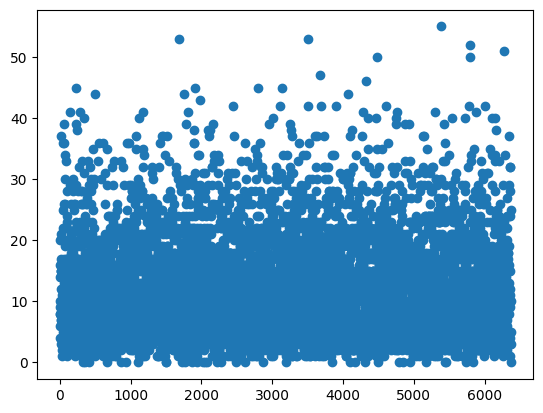

In [123]:
plt.scatter(df.index, df['missions_since_service'])
plt.show()
# No clear outliers seen in graph

# 2.5 Explore distributions and relationships

Before removing any attributes, create a compact summary table and
labelled histogram grid for the quantitative measurement and count
attributes. Exclude identifiers, administrative codes, categorical
labels, binary indicators, and the response, even if they are stored
numerically. At minimum, report the non-missing count, mean, standard
deviation, quartiles, minimum, maximum, and skewness.

Choose three attributes with different shapes. Discuss centre, spread,
symmetry or skewness, modality, and valid extreme observations.

**Detailed distribution analysis:**

Create a Pearson correlation heat map for the quantitative attributes.
Do not add identifiers, administrative codes, categorical encodings,
binary indicators, or the response unless specifically justified.
Discuss the strongest duplicate and non-duplicate relationships and
whether they are plausible. Add one joint plot involving at least two
attributes, and explain what it reveals beyond the univariate
histograms.

In [124]:
dfc = df.copy()
# For future reference, keeping original cleaned dataframe

dfc = df.drop(columns=['mission_id', 
                           'deployment_batch', 
                           'telemetry_protocol', 
                           'vehicle_class', 
                           'seabed_terrain', 
                           'maintenance_grade', 
                           'firmware_current',
                           'mission_interrupted'])
# Keep quantitative measurement and count attributes in a copy of the dataframe.

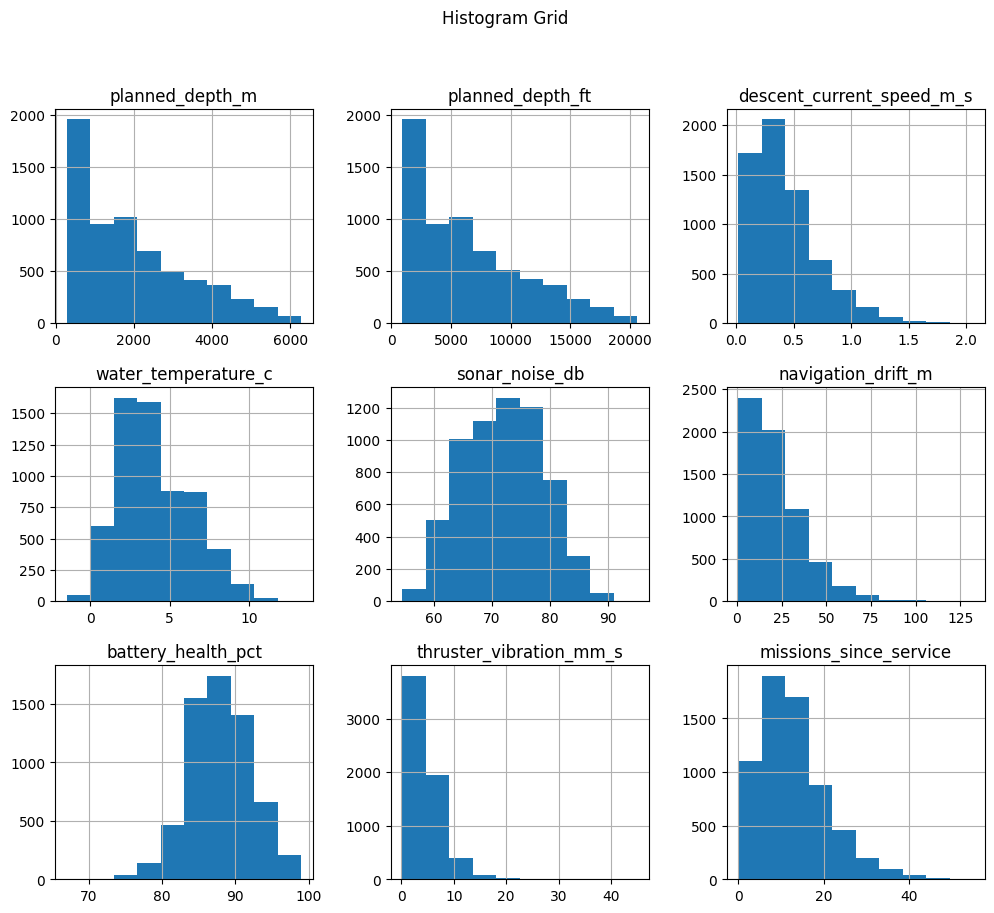

In [125]:
dfc.hist(figsize=(12, 10))

plt.suptitle('Histogram Grid')
plt.show()
# Here is the histogram

# Let's do a Statistical Analysis for each attribute above

## planned_depth_m Statistical Analysis

In [126]:
print("missing:", dfc['planned_depth_m'].isna().sum())
# Missing values

print(dfc['planned_depth_m'].describe().round(2))
# Non-null values count, mean, standard deviation, min, Q1 (25%), Q2 (50%), Q3 (75%), max values.

print("skew:", dfc['planned_depth_m'].skew().round(2))
# Skewness

missing: 6
count    6365.00
mean     1999.93
std      1402.26
min       280.00
25%       770.00
50%      1640.00
75%      2870.00
max      6290.00
Name: planned_depth_m, dtype: float64
skew: 0.93


## planned_depth_ft Statistical Analysis

In [127]:
print("missing:", dfc['planned_depth_ft'].isna().sum())
# Missing values

print(dfc['planned_depth_ft'].describe().round(2))
# Non-null values count, mean, standard deviation, min, Q1 (25%), Q2 (50%), Q3 (75%), max values.

print("skew:", dfc['planned_depth_ft'].skew().round(2))
# Skewness

missing: 0
count     6371.00
mean      6563.24
std       4599.60
min        918.60
25%       2559.10
50%       5380.60
75%       9416.00
max      20636.50
Name: planned_depth_ft, dtype: float64
skew: 0.92


## descent_current_speed_m_s Statistical Analysis

In [128]:
print("missing:", dfc['descent_current_speed_m_s'].isna().sum())
# Missing values

print(dfc['descent_current_speed_m_s'].describe().round(2))
# Non-null values count, mean, standard deviation, min, Q1 (25%), Q2 (50%), Q3 (75%), max values.

print("skew:", dfc['descent_current_speed_m_s'].skew().round(2))
# Skewness

missing: 6
count    6365.00
mean        0.42
std         0.29
min         0.02
25%         0.21
50%         0.36
75%         0.56
max         2.06
Name: descent_current_speed_m_s, dtype: float64
skew: 1.25


## water_temperature_c Statistical Analysis

In [129]:
print("missing:", dfc['water_temperature_c'].isna().sum())
# Missing values

print(dfc['water_temperature_c'].describe().round(2))
# Non-null values count, mean, standard deviation, min, Q1 (25%), Q2 (50%), Q3 (75%), max values.

print("skew:", dfc['water_temperature_c'].skew().round(2))
# Skewness

missing: 169
count    6202.00
mean        4.06
std         2.27
min        -1.50
25%         2.40
50%         3.60
75%         5.70
max        13.30
Name: water_temperature_c, dtype: float64
skew: 0.53


## sonar_noise_db Statistical Analysis

In [130]:
print("missing:", dfc['sonar_noise_db'].isna().sum())
# Missing values

print(dfc['sonar_noise_db'].describe().round(2))
# Non-null values count, mean, standard deviation, min, Q1 (25%), Q2 (50%), Q3 (75%), max values.

print("skew:", dfc['sonar_noise_db'].skew().round(2))
# Skewness

missing: 123
count    6248.00
mean       72.02
std         6.82
min        54.60
25%        66.70
50%        72.20
75%        77.10
max        95.00
Name: sonar_noise_db, dtype: float64
skew: 0.05


## navigation_drift_m Statistical Analysis

In [131]:
print("missing:", dfc['navigation_drift_m'].isna().sum())
# Missing values

print(dfc['navigation_drift_m'].describe().round(2))
# Non-null values count, mean, standard deviation, min, Q1 (25%), Q2 (50%), Q3 (75%), max values.

print("skew:", dfc['navigation_drift_m'].skew().round(2))
# Skewness

missing: 120
count    6251.00
mean       21.75
std        15.81
min         0.80
25%         9.80
50%        18.00
75%        29.30
max       132.20
Name: navigation_drift_m, dtype: float64
skew: 1.48


## battery_health_pct Statistical Analysis

In [132]:
print("missing:", dfc['battery_health_pct'].isna().sum())
# Missing values

print(dfc['battery_health_pct'].describe().round(2))
# Non-null values count, mean, standard deviation, min, Q1 (25%), Q2 (50%), Q3 (75%), max values.

print("skew:", dfc['battery_health_pct'].skew().round(2))
# Skewness

missing: 153
count    6218.00
mean       87.95
std         4.27
min        67.00
25%        85.00
50%        88.00
75%        91.00
max        99.00
Name: battery_health_pct, dtype: float64
skew: -0.24


## thruster_vibration_mm_s Statistical Analysis

In [133]:
print("missing:", dfc['thruster_vibration_mm_s'].isna().sum())
# Missing values

print(dfc['thruster_vibration_mm_s'].describe().round(2))
# Non-null values count, mean, standard deviation, min, Q1 (25%), Q2 (50%), Q3 (75%), max values.

print("skew:", dfc['thruster_vibration_mm_s'].skew().round(2))
# Skewness

missing: 126
count    6245.00
mean        4.65
std         3.14
min         0.20
25%         2.50
50%         3.90
75%         6.00
max        45.00
Name: thruster_vibration_mm_s, dtype: float64
skew: 2.19


## missions_since_service Statistical Analysis

In [134]:
print("missing:", dfc['missions_since_service'].isna().sum())
# Missing values

print(dfc['missions_since_service'].describe().round(2))
# Non-null values count, mean, standard deviation, min, Q1 (25%), Q2 (50%), Q3 (75%), max values.

print("skew:", dfc['missions_since_service'].skew().round(2))
# Skewness

missing: 0
count    6371.00
mean       12.61
std         7.86
min         0.00
25%         7.00
50%        11.00
75%        17.00
max        55.00
Name: missions_since_service, dtype: float64
skew: 1.11


## **Detailed distribution analysis (Part 1):**
Chosen attributes:
- planned_depth_m 
- sonar_noise_db
- battery_health_pct

Medians (Center):
 planned_depth_m       1640.0
sonar_noise_db          72.2
battery_health_pct      88.0
dtype: float64
Mode (Modality):
    planned_depth_m  sonar_noise_db  battery_health_pct
0            650.0            72.7                88.0


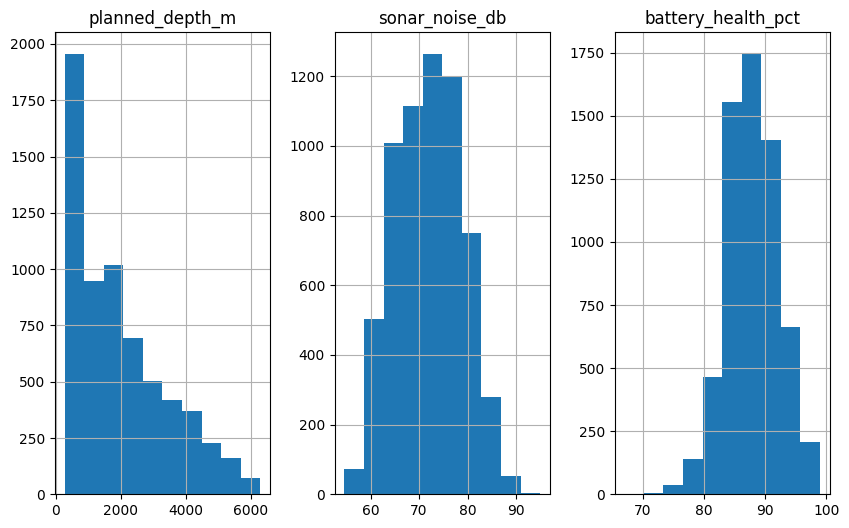

In [135]:
chosen = dfc[['planned_depth_m', 'sonar_noise_db', 'battery_health_pct']]
# Select chosen attribute in chosen variable

chosen.hist(figsize=(10, 6), layout=(1,3))
# Show the histograms of the 3 chosen attributes

print("Medians (Center):\n", chosen.median())
print("Mode (Modality):\n", chosen.mode())
# Calculate the Center and Modality, used to answer questions below

plt.show()
# See what were working with

## Observations

### Skew: 
1) planned_depth_m:
**Observation**: Very right skewed; we tend to want to explore in more shallow waters
2) sonar_noise_db:
**Observation**: Fairly not skewed, almost a perfect normal distribution; noise is not often light nor loud
3) battery_health_pct:
**Observation**: Slightly left skewed; battery tends to be more charged than not when running missions
### Center (meidans calculated above):
1) planned_depth_m:
**Observation**: The median is 1640 meters, so most values hang around the left side of the graph
2) sonar_noise_db:
**Observation**: The median is 72.2 db, so most values are around the loudness of the engine of a car
3) battery_health_pct: 
**Observation**: The median is 88%, so the battery health hangs around almost full
### Spread:
1) planned_depth_m: 
**Observation**: More values tend to be spread in more shallow waters
2) sonar_noise_db:
**Observation**: The spread values follow the center described above
3) battery_health_pct:
**Observation**: The values are spread in the 85-95% charged region
### Modality (mode calculated above):
1) planned_depth_m:
**Observation**: The mode is far different from the median, it stands at 650 meters, which is the most popular depth to explore
2) sonar_noise_db:
**Observation**: The mode is so very close to the median, it stands at 72.7 db, which, like the median is the most common decibell loudness
3) battery_health_pct:
**Observation**: The mode is equal to the median, it stands at 88%, which shows that the battery is almost always charged at 88% before missions
### Valid extreme observations (keep in mind: outliers have been substituted to NaN):
1) planned_depth_m:
**Observation**: Fairly plausible 5000+ meter explorations but conditions become harsher and not suitable for basic explorations
2) sonar_noise_db:
**Observation**: Some values are above 90. It is hard to think of situations where the equivalent of the noise of a helicopter was captured in the deep sea.
3) battery_health_pct:
**Observation**: All values within 60-100, nothing to discuss here.

## **Detailed distribution analysis (Part 2):**

Create a Pearson correlation heat map for the quantitative attributes.

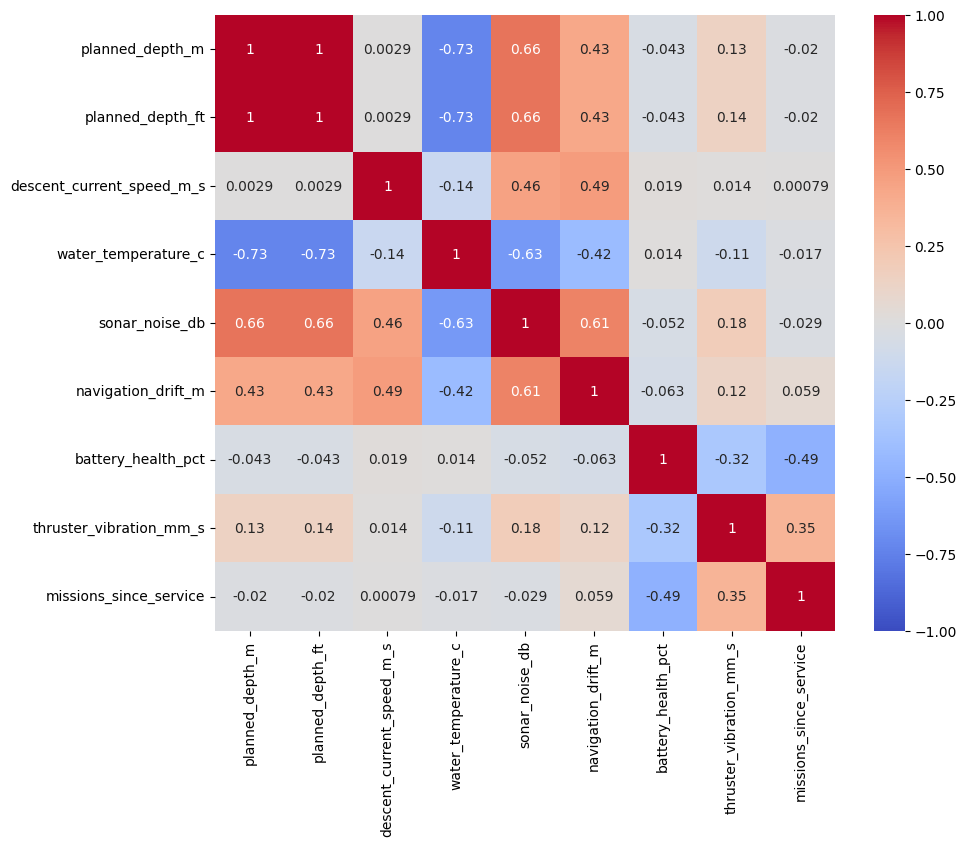

In [136]:
corr = dfc.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()
# Show heat map of column values correlation with seaborn

### Strong Duplicate relations
- **Observation:** planned_depth_m and planned_depth_ft are perfectly correlated. When one increases, the other increases proportionally. This is because they are a conversion of one-another, a mathematical multiplier.
- *Plausibility? :* **Ask mathematics, it'll say absolutely**
### Strong Non-Duplicate relations
- **Observation:** water_temperature_c and planned_depth_(m/ft) have the highest negative correlation. This shows that when one increases, the other drops.
- *Plausibility? :* **This makes sense, the deeper we go (++depth), the colder it gets (--water_temp)**
- **Observation:** sonar_noise_db and planned_depth_(m/ft) have the highest Non-duplicate correlation. This shows that when one increases, the other follows the same direction, not proportionally, but strongly.
- *Plausibility? :* **This makes sense, the deeper we go (++depth), properties of the ocean get louder and sound waves bend more (+sonar_noise)**

## Joint plot of planned_depth_m and water_temperature_c

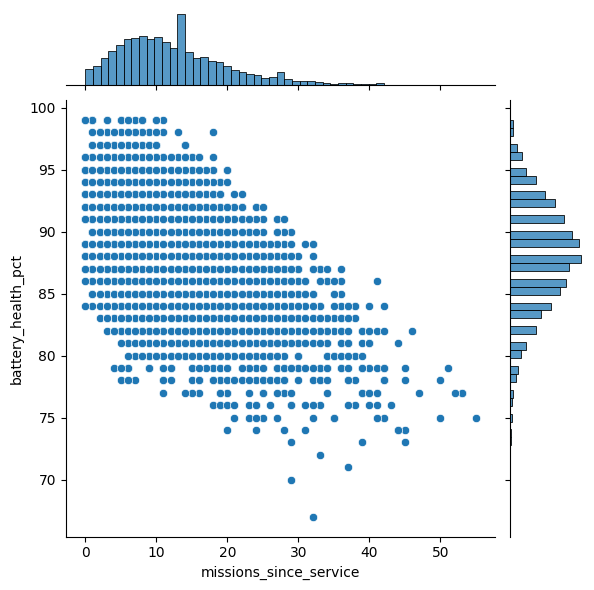

In [137]:
sns.jointplot(data=dfc, x="missions_since_service", y="battery_health_pct")
# Show joint plot of missions_since_service X battery_health_pct with seaborn

## What it reveals

- **Battery health tends to lower, the more missions are taken on without reservicing the machinery**. Which makes total sense, as they go on more missions, the battery will drain / may not be fully charged for the next mission.

# 2.6 Select attributes for the analysis-ready dataset
List and justify every removed attribute. Demonstrate a suspected deterministic
or alternate-unit duplicate with a direct numerical relationship, such
as a conversion error or residual; correlation alone is insufficient
evidence of duplication. Do not remove strongly correlated attributes
when they measure different concepts.

## planned_depth_m <--> planned_depth_ft Duplication Analysis
#### Trying to see if it's more than just correlation, if they are truly mathematically converted

In [138]:
METER_TO_FEET = 1 / 0.3048
df["is_exact_conversion"] = df["planned_depth_ft"].round(2) == (df["planned_depth_m"] * METER_TO_FEET).round(1)
# Check values based on universal conversion

df["is_exact_conversion"].value_counts()
# See some False values

is_exact_conversion
True     6355
False      16
Name: count, dtype: int64

In [139]:
mismatches = df[df["is_exact_conversion"] == False]
print(mismatches[["planned_depth_m", "planned_depth_ft", "is_exact_conversion"]])
# Analyze False values

      planned_depth_m  planned_depth_ft  is_exact_conversion
379            3750.0           12303.2                False
499               NaN            9416.0                False
1381           3750.0           12303.2                False
1443              NaN            7611.5                False
3084           3750.0           12303.2                False
3103           3750.0           12303.2                False
3173              NaN           10859.6                False
3210           5060.0           16601.1                False
3556           5060.0           16601.1                False
5192              NaN            4035.4                False
5247              NaN            6463.3                False
5384           5060.0           16601.1                False
5395              NaN           12401.6                False
5850           3750.0           12303.2                False
6285           5060.0           16601.1                False
6326           3750.0   

## Findings 1
### --> They are redundant
See that out of the conversion that Flagged False, they were flagged because of rouding .149 to .1 instead of .2 for exmaple. Everything else returns True, meaning the values both abide by the given conversion. The False values are not Falsely (except for NaN's). **Concludes that planned_depth_m and planned_depth_ft are exact mathematical conversion, not just correlated.**

## firmware_current & telemetry_protocol Analysis of Use and Similarity
#### Trying to see if they are redundant, mirrors of one-another

In [140]:
print(df['firmware_current'].value_counts())
print(df['telemetry_protocol'].value_counts())
# They both have cardinality of 2 but don't have similar distributions --> not a lead

firmware_current
1    5157
0    1214
Name: count, dtype: int64
telemetry_protocol
asrc_tlm_v4    6318
asrc_tlm_v3      53
Name: count, dtype: int64


## mission_id and deployment_batch Analysis of Use
#### Trying to see if there is a use for mission_id 's and deployement_batch (es)

In [141]:
df['mission_id'].nunique()
# Shows that mission_id's are all unique

6371

In [142]:
print("Unique deployments: ", df['deployment_batch'].nunique())
print(df['deployment_batch'].value_counts())
# Show unique deployments and amount of missions per deployments

Unique deployments:  850
deployment_batch
ASRC-B0001    8
ASRC-B0002    8
ASRC-B0003    8
ASRC-B0004    8
ASRC-B0005    8
             ..
ASRC-B0846    7
ASRC-B0847    7
ASRC-B0848    7
ASRC-B0849    7
ASRC-B0850    7
Name: count, Length: 850, dtype: int64


## Findings 2
### --> They are high-cardinality admin fields and **mission_id holds redundancy** unless specified otherwise
mission_id's are items (7 to 8) contained within deployment_batch(es) (850 deployments total). If we were to optimize the dataset, I would remove mission_id's, as it is a unique identifier whose values identify individual missions rather than describe characteristics of those missions, so it provides no extra meaningful info.

## Drop planned_depth_ft & mission_id

In [143]:
dfc2 = df.copy()
dfc2 = dfc2.drop(["planned_depth_ft", "mission_id", "is_exact_conversion"], axis=1)
# Dropped is_exact_conversion too, it was a temporary boolean column added to check ft:m conversion
dfc2.head()
# Show the Analysis-ready dataset

,deployment_batch,telemetry_protocol,planned_depth_m,descent_current_speed_m_s,water_temperature_c,sonar_noise_db,navigation_drift_m,battery_health_pct,thruster_vibration_mm_s,missions_since_service,vehicle_class,seabed_terrain,maintenance_grade,firmware_current,mission_interrupted
0,ASRC-B0253,asrc_tlm_v4,1400.0,0.55,3.3,66.0,10.4,87.0,3.1,14,compact,ridge,good,1,0
1,ASRC-B0648,asrc_tlm_v4,2700.0,0.68,3.0,78.5,49.9,83.0,3.9,4,heavy_duty,vent_field,good,1,1
2,ASRC-B0340,asrc_tlm_v4,2870.0,0.15,3.6,78.7,5.8,92.0,5.2,10,survey,vent_field,fair,1,1
3,ASRC-B0620,asrc_tlm_v4,2840.0,0.39,2.5,77.3,54.6,89.0,3.9,9,survey,trench,good,1,0
4,ASRC-B0332,asrc_tlm_v4,2430.0,0.34,2.8,77.8,8.7,89.0,3.4,8,heavy_duty,vent_field,excellent,1,0


# 2.7 Examine the response

Report counts and proportions for `mission_interrupted`, include a
labelled bar chart, and briefly characterize the class balance. Do not
train a model.

Text(0, 0.5, 'Total Count')

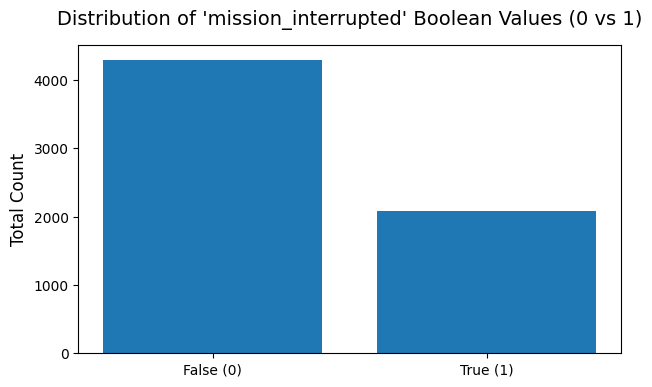

In [144]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["False (0)", "True (1)"], df['mission_interrupted'].value_counts())
# Simple graph plot to show mission_interrupted boolean value counts

ax.set_title("Distribution of 'mission_interrupted' Boolean Values (0 vs 1)", fontsize=14, pad=15)
ax.set_ylabel("Total Count", fontsize=12)
# Set titles

In [145]:
print("Value counts:\n", dfc2['mission_interrupted'].value_counts())
# Show value counts for both True (1) and False (0) values

print("Value percentages:\n", dfc2['mission_interrupted'].value_counts(normalize=True) * 100)
# Show percentage for both True (1) and False (0) values

Value counts:
 mission_interrupted
0    4295
1    2076
Name: count, dtype: int64
Value percentages:
 mission_interrupted
0    67.414849
1    32.585151
Name: proportion, dtype: float64


## mission_interrupted Conclusion

#### The mission was interrupted 2076 times (\~32%) and was not interrupted 4295 times (\~67%). The class is moderately imbalanced at a \~67/\~32 ratio. It tells us that 1 in every 3 missions tend to get interruped. 

# 2.8 Export the cleaned data

Retain the attributes you selected for the analysis-ready dataset and
`mission_interrupted`. Keep the retained predictors in their original
dataset order and place the response last. Leave unavailable or invalid
predictor measurements as `NaN`. Save the table as
`asrc_missions_cleaned.csv` without an index column. Reload the saved
CSV and verify its filename, shape, column names and order, categorical
labels, numeric measurements, missing values, row order, response, and
absence of an extra index column.

In [146]:
dfc2.to_csv("asrc_missions_cleaned.csv", index=False)
# Save cleaned dataframe to csv file

In [147]:
df_check = pd.read_csv("asrc_missions_cleaned.csv")
# reload csv file into a new dataframe

In [148]:
print("Original shape:", dfc2.shape)
print("Reloaded shape:", df_check.shape)
# Shape check

print("Same columns:", dfc2.columns.equals(df_check.columns))
# Column Check

Original shape: (6371, 15)
Reloaded shape: (6371, 15)
Same columns: True


In [149]:
(df["deployment_batch"].reset_index(drop=True) ==
 df_check["deployment_batch"].reset_index(drop=True)).all()
# Row order Check

np.True_

In [155]:
print("Middle-man dataset:\n", dfc2.dtypes)
print('\n')
print("Re-imported dataset:\n", df_check.dtypes)
# Categorical and numerical labels Check

# Note on Data Types: Exporting pandas DataFrames to the flat CSV format strips 
# explicit 'category' and 'object' type designations, defaulting them to standard strings.
# While the reimported data correctly aligns back to standard 'str' profiles, the 
# intermediate dataframe 'dfc2' intentionally utilized optimized 'category' and 'object' 
# datatypes. This divergence is structural due to the storage medium, not a runtime error, 
# as the structural optimization in 'dfc2' was explicitly configured to facilitate 
# efficient computational tasks.

Middle-man dataset:
 deployment_batch             category
telemetry_protocol           category
planned_depth_m               float64
descent_current_speed_m_s     float64
water_temperature_c           float64
sonar_noise_db                float64
navigation_drift_m            float64
battery_health_pct            float64
thruster_vibration_mm_s       float64
missions_since_service          int64
vehicle_class                  object
seabed_terrain                 object
maintenance_grade              object
firmware_current                int64
mission_interrupted             int64
dtype: object


Re-imported dataset:
 deployment_batch                 str
telemetry_protocol               str
planned_depth_m              float64
descent_current_speed_m_s    float64
water_temperature_c          float64
sonar_noise_db               float64
navigation_drift_m           float64
battery_health_pct           float64
thruster_vibration_mm_s      float64
missions_since_service         int64
v

In [151]:
dfc2.describe().equals(df_check.describe())
# Statistical Check (proves numeric measurements, missing values, response)

True

## Export Conclusion
#### The Shape is the same, the Columns have the same names, the columns of the re-imported dataset have the same datatypes as the original dataset (middle-man modified dataset excluded, see Note above), the Rows are in the same order, and their Statistical Values are the exact same.